# Bleaching Candidates from Three Subreddits

## Introduction

The 2019 paper Time-Out: Temporal Referencing for Robust Modeling of Lexical Semantic Change (Dubossarsky et al.) provides a powerful idea for embedding corpuses that allows direct year-to-year comparison using cosine similarity with fewer caveats than with Procrustes alignment. I used this technique in embedding three subreddits from [Cornell's ConvoKit](https://convokit.cornell.edu/): r/teenagers, r/relationship_advice, r/offmychest. r/offmychest and r/relationship_advice were both chosen for their narrative structure, while r/teenagers was chosen to capture a larger slice of slang. I expected slang usage to exist in all three.

I constructed a simple embedding pipeline (not present in this notebook) that downloaded all three subreddits and embedded them with the same setup from the paper. The only key difference was the acceleration of the algorithm; I used Hogwild! to speed up training, which adds some randomness to the vectors. This was offset by running 15 iterations, but the vectors might not be perfectly reproducible.

In [1]:
from gensim.models import KeyedVectors

wv = KeyedVectors.load_word2vec_format(
    "./vectors/sgns.words",
    binary=False
)

After some experimentation, I found that some rare words end up having volatile SimLex scores because they--and the synonyms associated--don't have stable cosine similarities over the years. I used the counts file from the embeddings to filter those words before calculating the SimLex scores.

In [2]:
counts = {}

with open("counts.words.vocab") as f:
    for line in f:
        token, count = line.split()
        word, year = token.rsplit("_", 1)
        counts[(word, int(year))] = int(count)

## SimLex

I tried implementing SimLex (from Luo et al.'s 2019 paper) using WordNet, which proved to be full of archaic synonyms for many of the slang words ("dandy" as a synonym for dude). I then switched to Wiktionary, which has many more synonyms for modern words and provides tagging for language and other features.

In [3]:
import json

from paths import WIKTIONARY_PATH

synonyms = {}

with open(WIKTIONARY_PATH, encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)

        if entry.get("pos") == "hard-redirect":
            continue

        if entry.get("lang_code") != "en":
            continue

        word = entry.get("word")
        if word is None:
            continue

        synonyms.setdefault(word, [])

        # Extract general synonyms (word-level)
        for synonym in entry.get("synonyms", []):
            if "obsolete" not in synonym.get("tags", []):
                synonyms[word].append(synonym["word"])

        # Extract sense-specific synonyms
        for sense in entry.get("senses", []):
            for synonym in sense.get("synonyms", []):
                if "obsolete" not in synonym.get("tags", []):
                    synonyms[word].append(synonym["word"])

In [4]:
stability = {}

In [5]:
def lemma_set(word):
    return set(synonyms.get(word, []))

To further prevent archaic words from impacting the SimLex score, I implemented both a weighted and unweighted version of the metric. The weighted version considers the cosine similarity of the target word to its synonyms, and then squares that value in making the weighted average. This prevents synonyms like dandy (which is listed for dude) from hijacking the score due to low occurrence and thus unstable cosine similarity.

Present in both functions is a minimum count parameter, which ensures that infrequent words don't create false signals of bleaching. The default is 150, which helps preserve a lot of infrequent slang usage in early years while also blocking out noise.

In [6]:
REQUIRED_YEARS = [2012, 2013, 2018]

def cos_weighted_simlex(word, year, min_L=1, min_count=150, p=2):
    if word not in synonyms:
        return None
    L = synonyms[word]

    if not all(f"{word}_{y}" in wv for y in REQUIRED_YEARS):
        return None

    w_counts = [counts.get((word, y), 0) for y in REQUIRED_YEARS]
    if not all(c >= min_count for c in w_counts):
        return None

    weights = {}
    for lw in L:
        if f"{lw}_2012" not in wv:
            continue
        if not all(f"{lw}_{y}" in wv for y in REQUIRED_YEARS):
            continue
        if lw not in stability:
            stability[lw] = wv.similarity(f"{lw}_2012", f"{lw}_2018")
        if stability[lw] > 0.0:
            weights[lw] = max(float(wv.similarity(f"{lw}_2012", f"{word}_2012")), 0.0)

    if len(weights) < min_L:
        return None

    raw = {l: s ** p for l, s in weights.items()}
    total = sum(raw.values())
    if total == 0:
        return None
    actual = {l: v / total for l, v in raw.items()}

    values = {}
    for lw in L:
        if f"{lw}_{year}" not in wv:
            continue
        values[lw] = float(wv.similarity(f"{lw}_{year}", f"{word}_{year}"))

    num = den = 0.0
    for lw in values:
        if lw in actual:
            num += actual[lw] * values[lw]
            den += actual[lw]
    return num / den if den > 0 else None

In [7]:
def cos_unweighted_simlex(word, year, min_L=1, min_count=150):
    L = lemma_set(word)

    if f"{word}_{year}" not in wv:
        return None

    w_counts = [counts.get((word, y), 0) for y in REQUIRED_YEARS]
    if not all(c >= min_count for c in w_counts):
        return None

    values = []
    for lw in L:
        if f"{lw}_2012" not in wv or f"{lw}_{year}" not in wv:
            continue
        if lw not in stability:
            stability[lw] = (wv.similarity(f"{lw}_2012", f"{lw}_2018")
                             if f"{lw}_2018" in wv else 0.0)
        if stability[lw] <= 0.0:
            continue
        values.append(float(wv.similarity(f"{word}_{year}", f"{lw}_{year}")))

    if len(values) < min_L:
        return None

    return sum(values) / len(values)

I also performed a manual check to make sure the filter wasn't rejecting a large portion of the corpus.

In [8]:
all_words = {w for (w, y) in counts}
floor_rejects = {
    w for w in all_words
    if not all(counts.get((w, y), 0) >= 150 for y in REQUIRED_YEARS)
}
reject_tokens = sum(c for (w, y), c in counts.items() if w in floor_rejects)
print(f"{len(floor_rejects)} of {len(all_words)} words fall below the floor "
      f"({reject_tokens / sum(counts.values()):.1%} of tokens)")

18367 of 41874 words fall below the floor (0.5% of tokens)


In [9]:
def simlex_slope(word, years, min_L=1, min_count=150):
    if word in synonyms:
        L = synonyms[word]
    else:
        return None
    xs, ys = [], []
    for y in years:
        if f"{word}_{y}" not in wv:
            continue
        v = cos_weighted_simlex(word, y, min_count=min_count)
        if v is not None:
            xs.append(int(y))
            ys.append(v)
    return (linregress(xs, ys).slope, len(L)) if len(xs) >= 3 else None

With the frequency-controlled metric implemented, I moved on to calculating the slope of each word in the corpus to surface the top 10 movers. More negative slopes = greater drift.

I had to be more creative with the filters to prevent emerging slang from being filtered; I added a PEAK_MIN_COUNT to require words to be common in at least one year.

In [10]:
from scipy.stats import linregress

SIMLEX_MIN_COUNT = 150

PEAK_MIN_COUNT   = 1000

stems = {w.rsplit("_", 1)[0] for w in wv.index_to_key if w.rsplit("_", 1)[-1].isdigit()}
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018]

simlex_slopes = {}
for word in stems:
    if max(counts.get((word, y), 0) for y in years) < PEAK_MIN_COUNT:
        continue
    s = simlex_slope(word, years, min_count=SIMLEX_MIN_COUNT)
    if s is not None:
        simlex_slopes[word] = s

top_ten = sorted(simlex_slopes.items(), key=lambda kv_: kv_[1])[:10]

In [11]:
print(top_ten)

[('synth', (np.float64(-0.057025608207498274), 1)), ('profanity', (np.float64(-0.048227625233786445), 3)), ('screamo', (np.float64(-0.046376265585422516), 1)), ('cyclist', (np.float64(-0.043604466531957896), 7)), ('restrained', (np.float64(-0.04351040401629039), 2)), ('spiked', (np.float64(-0.0433686809676602), 2)), ('peanut', (np.float64(-0.04310460282223565), 6)), ('gov', (np.float64(-0.04219305302415575), 2)), ('chorus', (np.float64(-0.042169440005506785), 1)), ('computing', (np.float64(-0.04170233130987201), 2))]


Some of the candidates have straightforward explanations, while others don't. Cyclist, profanity, and chorus probably could use more metrics backing their drift or verifying their uselessness.

## Jaccard Index/IoU

I then moved on to Jaccard index because it successfully surfaced relevant bleaching candidates on the Google Books corpus. Again, I applied a light frequency filter and a simple stopword filter.

In [12]:
# calculate Jaccard index (IoU) across two decades where d1 is the first decade and d2 is the second
def jaccard_index(d1, d2):
    return len(d1 & d2) / len(d1 | d2)

In [13]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

IOU_MIN_COUNT = 150

MIN_LEN   = 1
STOPWORDS = {
    "the", "an", "a", "to", "by", "for", "of", "in", "is", "it",
    "as", "at", "be", "or", "so", "and", "but", "not", "this", "that",
    "are", "was", "were", "has", "had", "have", "been", "will", "can",
    "from", "with", "they", "their", "there", "than", "then", "when",
    "which", "who", "how", "its", "did", "get", "got", "may", "him",
    "her", "his", "our", "out", "one", "all", "any", "few", "now",
    "each", "more", "also", "both", "nor", "yet", "these", "those",
    "mr", "ms", "dr", "vs", "etc", "per", "via", "versa",
}

base_words = set()
for word in wv.index_to_key:
    base = word.rsplit("_", 1)[0]
    if (len(base) >= MIN_LEN
            and base not in STOPWORDS
            and max(counts.get((base, y), 0) for y in range(2012, 2019)) >= PEAK_MIN_COUNT
            and all(
                f"{base}_{year}" in wv.key_to_index
                and counts.get((base, year), 0) >= IOU_MIN_COUNT
                for year in range(2012, 2019)
            )):
        base_words.add(base)

print(f"{len(base_words)} base words after frequency + stopword filter")
base_words_list = list(base_words)

year_words = {}
year_models = {}
for year in range(2012, 2019):
    words = [w for w in wv.index_to_key if w.endswith(f"_{year}")]
    vectors = np.array([wv[w] for w in words])
    year_words[year] = words
    year_models[year] = NearestNeighbors(
        n_neighbors=26, metric="cosine", algorithm="brute"
    ).fit(vectors)

iou = {word: [] for word in base_words_list}

for year in range(2013, 2019):
    d1, d2 = year - 1, year

    v1_batch = np.array([wv[f"{word}_{d1}"] for word in base_words_list])
    v2_batch = np.array([wv[f"{word}_{d2}"] for word in base_words_list])

    _, d1_batch = year_models[d1].kneighbors(v1_batch)
    _, d2_batch = year_models[d2].kneighbors(v2_batch)

    d1_w = year_words[d1]
    d2_w = year_words[d2]

    for i, word in enumerate(base_words_list):
        nbrs_d1 = set(d1_w[j].rsplit("_", 1)[0] for j in d1_batch[i][1:])
        nbrs_d2 = set(d2_w[j].rsplit("_", 1)[0] for j in d2_batch[i][1:])
        iou[word].append(jaccard_index(nbrs_d1, nbrs_d2))

17018 base words after frequency + stopword filter


In [14]:
sorted_iou = sorted(iou.items(), key=lambda x: np.mean(x[1]))

years = list(range(2013, 2019))
header = f"{'word':<20} {'mean':>6}  " + "  ".join(str(y) for y in years)
print(header)
print("-" * len(header))

for word, iou_values in sorted_iou[:50]:
    year_cols = "  ".join(f"{v:.3f}" for v in iou_values)
    print(f"{word:<20} {np.mean(iou_values):>6.3f}  {year_cols}")

word                   mean  2013  2014  2015  2016  2017  2018
---------------------------------------------------------------
whit                  0.003  0.000  0.020  0.000  0.000  0.000  0.000
fro                   0.003  0.020  0.000  0.000  0.000  0.000  0.000
prod                  0.003  0.000  0.000  0.020  0.000  0.000  0.000
fore                  0.003  0.000  0.020  0.000  0.000  0.000  0.000
hen                   0.007  0.020  0.000  0.000  0.020  0.000  0.000
shutdown              0.007  0.000  0.000  0.000  0.020  0.000  0.020
alls                  0.007  0.000  0.020  0.000  0.000  0.020  0.000
raven                 0.007  0.000  0.042  0.000  0.000  0.000  0.000
fir                   0.010  0.000  0.020  0.000  0.000  0.020  0.020
bishop                0.010  0.000  0.000  0.020  0.020  0.020  0.000
tanner                0.010  0.000  0.000  0.000  0.000  0.042  0.020
submarine             0.010  0.000  0.042  0.020  0.000  0.000  0.000
ka                    0.010  0.0

Again, none of these candidates seem perfect. IoU is especially sensitive for rare words, which is probably how fir, fore, and fro ended up topping the list. IoU scores of 0 imply they never had a stable neighborhood to begin with.

## Cosine Drift

The third metric I examined was raw cosine similarity between a word's 2012 and 2018 vectors. I ended up loosening the frequency requirements the most here; previously, words like trump and savage had been excluded because they had low occurrences early on.

In [15]:
COS_MIN_COUNT = 150

cos_words = set()
for word in stems:
    if (len(word) >= MIN_LEN
            and word not in STOPWORDS
            and f"{word}_2012" in wv.key_to_index
            and f"{word}_2018" in wv.key_to_index
            and counts.get((word, 2012), 0) >= COS_MIN_COUNT
            and counts.get((word, 2018), 0) >= COS_MIN_COUNT
            and max(counts.get((word, y), 0) for y in years) >= PEAK_MIN_COUNT):
        cos_words.add(word)

print(f"{len(cos_words)} words eligible for cosine drift (2012 & 2018 count >= {COS_MIN_COUNT}, peak >= {PEAK_MIN_COUNT})")

cos_drift = {}
for word in cos_words:
    w1, w2 = f"{word}_2012", f"{word}_2018"
    cos_drift[word] = float(wv.similarity(w1, w2))

17057 words eligible for cosine drift (2012 & 2018 count >= 150, peak >= 1000)


## Combining Metrics

Finally, I opted to combine SimLex, Jaccard index, and cosine similarity to obtain a final ranking of candidates in the corpus. I initially started with z-score.

In [16]:
import numpy as np

common_words = simlex_slopes.keys() & iou.keys() & cos_drift.keys()
print(len(common_words), "words scored on all three metrics")

simlex_vals = np.array([simlex_slopes[w][0] for w in common_words])
iou_vals = np.array([np.mean(iou[w]) for w in common_words])
cosine_vals = np.array([cos_drift[w] for w in common_words])

iou_mu, iou_sigma = iou_vals.mean(), iou_vals.std(ddof=1)
cosine_mu, cosine_sigma = cosine_vals.mean(), cosine_vals.std(ddof=1)
simlex_mu, simlex_sigma = simlex_vals.mean(), simlex_vals.std(ddof=1)

6164 words scored on all three metrics


In [17]:
def zscore(value, mu, sigma):
    return (value - mu) / sigma

In [18]:
z_scores = {
    word: {
        "simlex": zscore(simlex_slopes[word][0], simlex_mu, simlex_sigma),
        "iou": zscore(np.mean(iou[word]), iou_mu, iou_sigma),
        "cosine": zscore(cos_drift[word], cosine_mu, cosine_sigma),
    }
    for word in common_words
}

z_simlex = np.array([z_scores[word]["simlex"] for word in common_words])
z_iou    = np.array([z_scores[word]["iou"]    for word in common_words])
z_cos    = np.array([z_scores[word]["cosine"] for word in common_words])

composite_z = {word: z["simlex"] + z["iou"] for word, z in z_scores.items()}
top_composite = sorted(composite_z.items(), key=lambda kv: kv[1])[:20]

header = f"{'word':<20} {'z_simlex':>9} {'z_iou':>9} {'z_cosine':>9} {'composite':>10}"
print(header)
print("-" * len(header))
for word, comp in top_composite:
    z = z_scores[word]
    print(f"{word:<20} {z['simlex']:>9.3f} {z['iou']:>9.3f} {z['cosine']:>9.3f} {comp:>10.3f}")

word                  z_simlex     z_iou  z_cosine  composite
-------------------------------------------------------------
synth                   -6.131    -0.302    -0.988     -6.433
profanity               -5.146    -1.229    -0.858     -6.375
spiked                  -4.601    -1.686    -2.652     -6.287
cyclist                 -4.628    -1.500    -2.172     -6.128
restrained              -4.617    -1.358    -1.271     -5.976
phantom                 -4.388    -1.363    -1.073     -5.752
jazzy                   -3.983    -1.596    -2.939     -5.579
woodwork                -3.709    -1.811    -2.068     -5.521
masses                  -3.998    -1.441    -1.098     -5.439
chorus                  -4.467    -0.953    -1.156     -5.420
spikes                  -3.813    -1.571    -1.667     -5.384
receiver                -3.617    -1.731    -1.178     -5.348
transmission            -4.290    -0.982     0.251     -5.271
dreads                  -3.648    -1.607    -2.703     -5.255
surgical

Some of the top 20 z-scored candidates seem ok, while others clearly have more complex explanations. The biggest issue with z-score, however, was that many of the values fell outside the -3 to 3 range expected using the metric. The first time I ran the notebook, I had implemented a frequency filter that created a more normal distribution for cosine similarity. Regardless, there was a very large tail on the left side of the data, making cosine the dominant metric for candidates. I ended up excluding cosine from the z-score sum entirely (the column is just for reference). I investigated the distribution of the data to find a better way to score all the words.

In [19]:
import plotly.express as px

common_keys = cos_drift.keys() & iou.keys()

cosine_vs_iou = {
    k: (cos_drift[k], sum(iou[k]) / len(iou[k]))
    for k in common_keys
}

xs, ys = zip(*cosine_vs_iou.values())
keys = list(cosine_vs_iou.keys())

fig = px.scatter(x=xs, y=ys, hover_name=keys,
                 labels={'x': 'cosine similarity', 'y': 'mean IoU'})
fig.show()

In [20]:
import plotly.express as px

common_keys = iou.keys() & cos_drift.keys()

simlex_vs_iou = {
    k: (sum(iou[k]) / len(iou[k]), cos_drift[k])
    for k in common_keys
}

xs, ys = zip(*simlex_vs_iou.values())
keys = list(simlex_vs_iou.keys())

fig = px.scatter(x=ys, y=xs, hover_name=keys,
                 labels={'x': 'mean IoU', 'y': 'SimLex'})
fig.show()

In [21]:
import plotly.express as px

common_keys = simlex_slopes.keys() & iou.keys()

simlex_vs_iou = {
    k: (simlex_slopes[k][0], sum(iou[k]) / len(iou[k]))
    for k in common_keys
}

xs, ys = zip(*simlex_vs_iou.values())
keys = list(simlex_vs_iou.keys())

fig = px.scatter(x=ys, y=xs, hover_name=keys,
                 labels={'x': 'mean IoU', 'y': 'SimLex'})
fig.show()

I also investigated the distribution of the metrics.

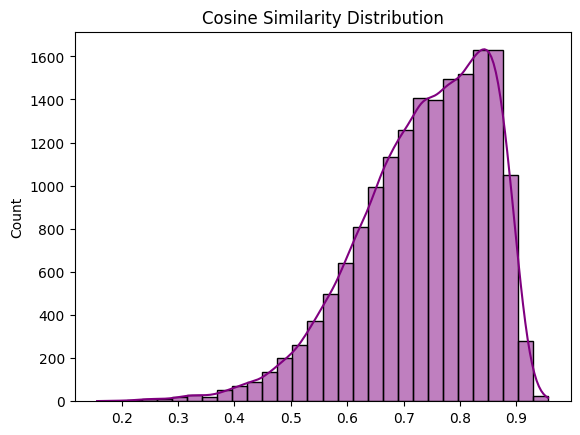

In [22]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Create a histogram with a smooth density line (KDE)
sns.histplot(cos_drift, bins=30, kde=True, color='purple')

plt.title('Cosine Similarity Distribution')
plt.show()

Cosine similarity has one of the most striking tails; the left side of the graph is relatively sparse, but picks up around 0.5. The right side, on the other hand, drops off quickly near 0.9. The sharp increase on the left is relatively expected given that high-stability words are more common than high-drift words, especially considering the size of the dataset.

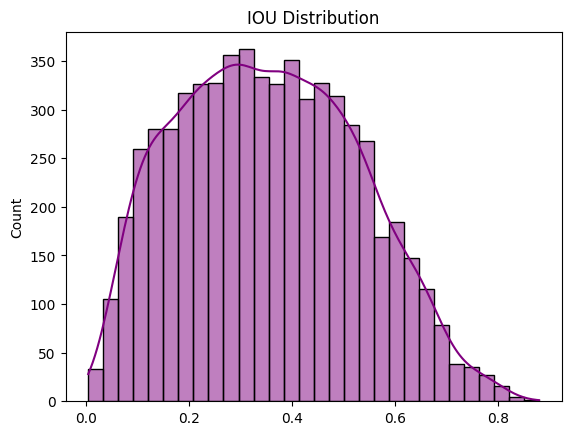

In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Create a histogram with a smooth density line (KDE)
sns.histplot(iou_vals, bins=30, kde=True, color='purple')

plt.title('IOU Distribution')
plt.show()

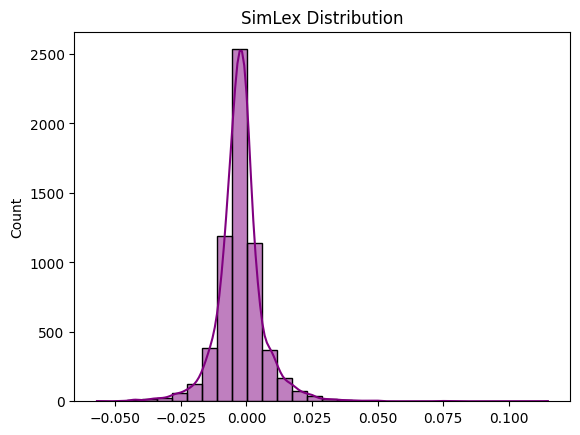

In [24]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Create a histogram with a smooth density line (KDE)
sns.histplot(simlex_vals, bins=30, kde=True, color='purple')

plt.title('SimLex Distribution')
plt.show()

Both the IoU and SimLex show a much more normal distribution. IoU has a strong right tail--the inverse of cosine drift--but likely shares the same explanation. SimLex is probably the most trustworthy; the synonyms came from a high-quality dictionary and underwent rigorous filtering for language and relevance.

I decided to use rank-based scoring to identify 20 bleaching candidates from the dataset. This mostly avoids the distribution problem and moves from focusing on the raw values to focusing on what they mean in context.

In [25]:
from scipy.stats import rankdata

RANK_MIN_COUNT = 150

common_words = [
    w for w in simlex_slopes.keys() & iou.keys() & cos_drift.keys()
    if counts.get((w, 2012), 0) >= RANK_MIN_COUNT and counts.get((w, 2018), 0) >= RANK_MIN_COUNT
]
print(len(common_words), "words scored on all three metrics after light frequency filter")

simlex_vals = np.array([simlex_slopes[w][0] for w in common_words])
iou_vals    = np.array([np.mean(iou[w])      for w in common_words])
cosine_vals = np.array([cos_drift[w]          for w in common_words])

r_simlex = rankdata(simlex_vals) / len(simlex_vals)
r_iou    = rankdata(iou_vals)    / len(iou_vals)
r_cosine = rankdata(cosine_vals) / len(cosine_vals)

ranks = {
    word: {"simlex": r_simlex[i], "iou": r_iou[i], "cosine": r_cosine[i]}
    for i, word in enumerate(common_words)
}

composite_rank = {word: r["simlex"] + r["iou"] + r["cosine"] for word, r in ranks.items()}
top_composite = sorted(composite_rank.items(), key=lambda kv: kv[1])[:20]

header = f"{'word':<20} {'r_simlex':>9} {'r_iou':>9} {'r_cosine':>9} {'composite':>10}"
print(header)
print("-" * len(header))
for word, comp in top_composite:
    r = ranks[word]
    print(f"{word:<20} {r['simlex']:>9.3f} {r['iou']:>9.3f} {r['cosine']:>9.3f} {comp:>10.3f}")

6164 words scored on all three metrics after light frequency filter
word                  r_simlex     r_iou  r_cosine  composite
-------------------------------------------------------------
fatherhood               0.006     0.011     0.007      0.024
fore                     0.023     0.000     0.002      0.025
crocodile                0.008     0.005     0.023      0.036
spiked                   0.001     0.021     0.016      0.038
neutrality               0.014     0.026     0.001      0.041
poppy                    0.017     0.002     0.025      0.045
woodwork                 0.003     0.008     0.036      0.047
uncreative               0.017     0.022     0.010      0.050
jazzy                    0.003     0.037     0.012      0.051
git                      0.021     0.028     0.005      0.054
dreads                   0.004     0.035     0.015      0.055
raven                    0.045     0.001     0.011      0.057
chief                    0.021     0.031     0.007      0.059
co

While the candidates seem better than the z-scored list, some of them still don't make a ton of sense (fatherhood, fore, and crocodile, for example). I looked for potential explanations in the nearest neighbors for each candidate.

In [43]:
def year_neighbors(word, year, topn=10, pool=5000):
    return [n for n, _ in wv.most_similar(f"{word}_{year}", topn=pool)
            if n.endswith(f"_{year}") and n.rsplit("_", 1)[0] != word][:topn]

for word, comp in top_composite:
    print("======")
    for y in [2012, 2013, 2014, 2015, 2016, 2017, 2018]:
        nbrs = ", ".join(year_neighbors(word, y))

        print(f"{word}_{y} (n={counts.get((word, y), 0)}): {nbrs}")

fatherhood_2012 (n=213): undisputed_2012, penalize_2012, unwed_2012, hehehehehe_2012, stepparent_2012, oppressor_2012, subsidizing_2012, kel_2012, lori_2012, evaded_2012
fatherhood_2013 (n=711): committment_2013, motherhood_2013, fathering_2013, conceding_2013, inaction_2013, responsibility_2013, marriage_2013, responsability_2013, veganism_2013, adulthood_2013
fatherhood_2014 (n=451): motherhood_2014, contrition_2014, nuptials_2014, endeavour_2014, payoff_2014, absolves_2014, millenial_2014, longevity_2014, encapsulates_2014, detests_2014
fatherhood_2015 (n=554): precludes_2015, sighting_2015, legislation_2015, unplanned_2015, forcible_2015, aborting_2015, parental_2015, terminating_2015, parenthood_2015, motherhood_2015
fatherhood_2016 (n=1490): boycotting_2016, marriage_2016, ordained_2016, american_2016, motherhood_2016, fathering_2016, womanhood_2016, housewives_2016, romanticised_2016, worshipping_2016
fatherhood_2017 (n=337): alteration_2017, cuckoldry_2017, reproduction_2017, s

ValueError: too many values to unpack (expected 2)

In [44]:
word = "fam"
print("======")
for y in [2012, 2013, 2014, 2015, 2016, 2017, 2018]:
    nbrs = ", ".join(year_neighbors(word, y))
    print(f"{word}_{y} (n={counts.get((word, y), 0)}): {nbrs}")

fam_2012 (n=370): familiy_2012, family_2012, oilers_2012, badgers_2012, canucks_2012, holidays_2012, bruins_2012, cape_2012, nieces_2012, binoculars_2012
fam_2013 (n=3727): bruh_2013, dawg_2013, homie_2013, brah_2013, bud_2013, brotha_2013, boi_2013, yo_2013, bro_2013, mang_2013
fam_2014 (n=3035): homies_2014, homie_2014, dawg_2014, bro_2014, brah_2014, bud_2014, boi_2014, bruh_2014, broski_2014, niggah_2014
fam_2015 (n=10967): bruh_2015, bro_2015, homie_2015, brah_2015, lmao_2015, lol_2015, jk_2015, dawg_2015, tho_2015, ay_2015
fam_2016 (n=19132): homie_2016, bruh_2016, bro_2016, boi_2016, dawg_2016, lmao_2016, ay_2016, brah_2016, mang_2016, bruv_2016
fam_2017 (n=23739): bro_2017, homie_2017, mang_2017, bruh_2017, bb_2017, ay_2017, bby_2017, ayyy_2017, bruv_2017, boyo_2017
fam_2018 (n=23745): bro_2018, homie_2018, bruv_2018, dood_2018, broski_2018, ayy_2018, bruh_2018, aye_2018, bud_2018, vro_2018


In [45]:
print(iou["fam"])

[0.0, 0.35135135135135137, 0.19047619047619047, 0.5151515151515151, 0.7241379310344828, 0.5625]



### Candidates

#### Spiked

Spiked is the first real example of semantic change. It starts off mostly focused on fashion, but it slowly drifts towards drinks and drugs (drugged and tequila by 2018).

#### Chief

Chief is a fantastic example. The embedding starts focused on rap (Chief Keef, Lil Wayne, Sosa, etc.). However, by 2018, the usage has exploded and the neighbors are bro, fam, and mate, demonstrating a shift towards a title or placeholder nickname.

#### Neutrality

Neutrality also experiences a significant shift. The 2012 embedding centers around religious neutrality and government neutrality, but its usage drifts more specifically towards net neutrality with an emerging focus on the United States, as suggested by the neighbors trump, constitutional and repeal.

#### Uncreative

Uncreative appears to drift from an insult for a person to a more general description for media by 2018.

### Noise
#### Fatherhood

Fatherhood seems to have been affected heavily by noise early on. The neighbors from 2012 are not coherent with the dictionary meaning, likely resulting in a skewed SimLex slope and also cosine similarity. The word does stabilize after 2013, but is affected by relationship- and parenting-related terms that reflect the corpus distribution.

#### Fore

Fore doesn't have as clean of an explanation, and seems relatively unstable throughout the investigated period. The neighbors early on seem to reflect the literal meaning--to be at the front of something--but the embeddings from 2016 onward weaken that conclusion.

#### Crocodile

Crocodile appears to experience the same issue as fatherhood; its initial neighborhoods are slightly unfocused, but it eventually becomes associated with the phrase crocodile tears.

This is not an exhaustive list, but exemplifies some of the patterns from the data.

## Conclusion

This notebook demonstrates the efficacy of the embedding pipeline based on Cornell ConvoKit and the value of SimLex, even when based off a different backend dictionary. However, noise still presents a challenge in automatically surfacing relevant bleaching candidates. Typos and cultural shifts created false signals that were picked up due to inaccurate vectors (low cosine similarity) and unstable neighborhoods (low IoU). Training embeddings on a larger corpus may add additional appearances of typos, stabilizing their vectors. Effectively tuning the frequency parameters to exclude noise while including infrequent words was challenging and likely could be alleviated by using a hard-coded list or leveraging a model to identify misspellings with high accuracy.